In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0,'../g3algo/')
import foftools as fof

In [56]:
eco = pd.read_csv("ECOdata_G3catalog_luminosity.csv")

In [57]:
eco = eco[eco.dedeg<7]

<IPython.core.display.Javascript object>


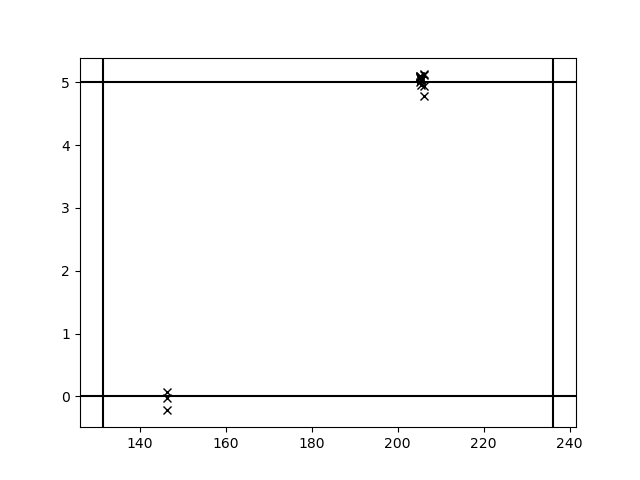

In [58]:
%matplotlib notebook
plt.figure()
sel = (eco['sky-cutoff-flag']==0)
#plt.scatter(eco.radeg[sel],eco.dedeg[sel],c=eco.g3grp_l[sel],s=1,cmap='hsv')

ra=eco.radeg[sel].to_numpy()
dec=eco.dedeg[sel].to_numpy()
g3grp=eco.g3grp_l[sel].to_numpy()
#for ii in range(0,len(ra)):
#    plt.annotate(str(g3grp[ii]),(ra[ii]+0.01,dec[ii]+0.01))

plt.plot(eco.radeg[~sel],eco.dedeg[~sel],'kx')
plt.axhline(5,color='k')
plt.axhline(0,color='k')
plt.axvline(131.25,color='k')
plt.axvline(236.25,color='k')

In [68]:
yy=eco[~sel][['name','radeg','dedeg','cz','sky-cutoff-flag']].sort_values(by='name')
print(yy)
print(yy.shape)


           name      radeg   dedeg           cz  sky-cutoff-flag
1584   ECO01585  206.16760  5.1117  7100.529236              1.0
4242   ECO04243  205.06709  5.0764  6892.125367              1.0
4248   ECO04249  205.27170  5.1058  6943.683806              1.0
4249   ECO04250  205.34419  5.0403  6989.610887              1.0
4250   ECO04251  205.41380  5.0328  6941.777291              1.0
4266   ECO04267  206.14079  4.7758  6958.600000              1.0
5360   ECO05361  146.23199  0.0683  6295.900000              1.0
5581   ECO05582  146.16251 -0.2219  6318.700000              1.0
6396   ECO06397  206.10370  5.1253  6937.886621              1.0
6398   ECO06399  206.17250  4.9420  6837.400000              1.0
7146   ECO07147  205.30090  5.0543  6988.541115              1.0
7663   ECO07664  205.33321  4.9564  7051.800000              1.0
7668   ECO07669  205.11430  5.0123  6723.502283              1.0
7671   ECO07672  205.49339  5.0323  7313.062424              1.0
7673   ECO07674  205.1355

# test using different method

In [74]:
x1=eco.groupby('g3grp_l').filter(lambda grp: ((grp.dedeg>5).any() and (grp.dedeg<5).any()))[['name','radeg','dedeg','cz','sky-cutoff-flag']]
x2=eco.groupby('g3grp_l').filter(lambda grp: ((grp.dedeg>0).any() and (grp.dedeg<0).any()))[['name','radeg','dedeg','cz','sky-cutoff-flag']]
x3=eco.groupby('g3grp_l').filter(lambda grp: ((grp.radeg>131.25).any() and (grp.radeg<131.25).any()))[['name','radeg','dedeg','cz','sky-cutoff-flag']]
x4=eco.groupby('g3grp_l').filter(lambda grp: ((grp.radeg<236.25).any() and (grp.dedeg>236.25).any()))[['name','radeg','dedeg','cz','sky-cutoff-flag']]
xx=pd.concat([x1,x2,x3,x4])
print(xx.sort_values(by='name'))
print(xx.shape)

           name      radeg   dedeg           cz  sky-cutoff-flag
1584   ECO01585  206.16760  5.1117  7100.529236              1.0
4242   ECO04243  205.06709  5.0764  6892.125367              1.0
4248   ECO04249  205.27170  5.1058  6943.683806              1.0
4249   ECO04250  205.34419  5.0403  6989.610887              1.0
4250   ECO04251  205.41380  5.0328  6941.777291              1.0
4266   ECO04267  206.14079  4.7758  6958.600000              1.0
5360   ECO05361  146.23199  0.0683  6295.900000              1.0
5581   ECO05582  146.16251 -0.2219  6318.700000              1.0
6396   ECO06397  206.10370  5.1253  6937.886621              1.0
6398   ECO06399  206.17250  4.9420  6837.400000              1.0
7146   ECO07147  205.30090  5.0543  6988.541115              1.0
7663   ECO07664  205.33321  4.9564  7051.800000              1.0
7668   ECO07669  205.11430  5.0123  6723.502283              1.0
7671   ECO07672  205.49339  5.0323  7313.062424              1.0
7673   ECO07674  205.1355

# test with katie's group catalog

In [48]:
df = pd.read_csv("ECOdata_051123.csv")
df = df[df.grp>0]
df.loc[:,'scflag'] = fof.get_skycutoff_flag_RESA(df.radeg,df.dedeg,df.grp)

In [49]:
df[df.scflag>0][['name','radeg','dedeg','cz','grp']].describe()

,radeg,dedeg,cz,grp
count,19.000000,19.000000,19.000000,19.000000
mean,180.777813,2.929853,6510.301746,2952.736842
std,29.988477,2.544990,576.108245,1460.991286
min,136.336300,-0.036900,5457.600000,422.000000
25%,146.312095,0.049800,6290.400000,3304.000000
50%,205.076100,4.956400,6837.440858,3304.000000
75%,205.286300,5.059250,6966.112460,3304.000000
max,205.466400,5.105800,7051.800000,5160.000000


<IPython.core.display.Javascript object>


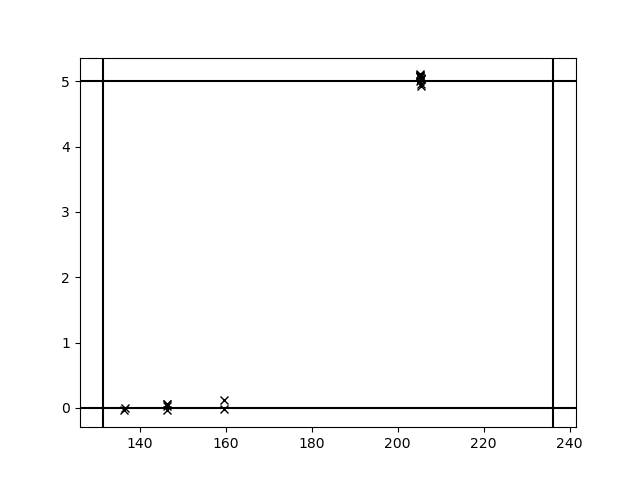

In [51]:
plt.figure()
sel = (df.scflag==1)
plt.plot(df.radeg[sel],df.dedeg[sel],'kx')
plt.axhline(5,color='k')
plt.axhline(0,color='k')
plt.axvline(131.25,color='k')
plt.axvline(236.25,color='k')
plt.show()